In [186]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')
from sklearn import preprocessing

In [2]:
ROOT_DIR = Path('.').resolve().parents[0].absolute()
DATA_DIR = ROOT_DIR /'dataset'

In [3]:
target_column = 'Net Sales'

# Dataset

In [4]:
financial_data = pd.read_excel(DATA_DIR/'financial_data.xlsx', header=4, usecols='B:F')
financial_data.head()

,Products,Year,Net Sales,Advertising Spend (A),Promotion Spend (P)
0,Brand 3,2017.01,3.324572e+06,141943.45955,70620.349235
1,Brand 1,2017.01,8.692541e+06,118484.23094,122556.189118
2,Brand 2,2017.01,7.409735e+06,158771.21121,134664.104787
3,Brand 3,2017.02,4.018024e+06,191409.99457,105655.592949
4,Brand 1,2017.02,8.248312e+06,347990.67781,160664.657435


In [5]:
financial_data.shape

(144, 5)

In [6]:
marketing_data = pd.read_excel(DATA_DIR/ 'other_marketing_data.xlsx')
marketing_data.head()

,BRAND,DATE,RATE OF INNOVATION,PRICE PER VOLUME,TDP,SHARE OF VOICE,NET SALES OF COMPETITOR #1,NET SALES OF COMPETITOR #2,PRICE PER VOLUME COMPETITOR #1,MARKET SIZE - SUB MARKET 1,...,MARKET SIZE - SUB MARKET 12,MARKET SIZE - SUB MARKET 13,MARKET SIZE - SUB MARKET 14,MARKET SIZE - SUB MARKET 15,MARKET SIZE - SUB MARKET 16,POPULATION - 0 À 19 ANS,POPULATION - 20 À 39 ANS,POPULATION - 40 À 59 ANS,POPULATION - 60 À 74 ANS,POPULATION - 75 ANS ET PLUS
0,BRAND 1,2018-03-01,1.408282,8.317322,110.011542,45.192,4.032382e+06,2.691472e+08,15.004156,4.390130e+06,...,3.606671e+07,1.032834e+07,3.296905e+07,7.829776e+06,7.848957e+06,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04
1,BRAND 1,2018-04-01,1.396744,8.908931,109.830905,63.484,5.264635e+06,3.269989e+08,15.484910,5.774614e+06,...,4.150016e+07,1.300159e+07,4.234487e+07,9.093001e+06,1.124655e+07,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04
2,BRAND 1,2018-05-01,1.731032,9.249615,109.854779,55.952,4.339679e+06,2.583341e+08,15.653820,4.933605e+06,...,3.093176e+07,1.117407e+07,3.410793e+07,7.515288e+06,9.221574e+06,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04
3,BRAND 1,2018-06-01,1.735802,9.064674,109.904309,32.280,4.651524e+06,2.546303e+08,15.675915,4.559039e+06,...,2.858196e+07,9.730342e+06,3.304539e+07,7.200092e+06,8.915028e+06,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04
4,BRAND 1,2018-07-01,1.509909,9.176992,109.889601,37.660,5.723941e+06,3.152492e+08,15.365394,5.336451e+06,...,3.608451e+07,1.262302e+07,4.301778e+07,8.473812e+06,9.464171e+06,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04


In [7]:
marketing_data.shape

(102, 30)

# Preprocessing

In [8]:
financial_data.dtypes

Products                  object
Year                     float64
Net Sales                float64
Advertising Spend (A)    float64
Promotion Spend (P)      float64
dtype: object

In [9]:
# Checking if there are any null values
financial_data.isnull().sum()

Products                 0
Year                     0
Net Sales                0
Advertising Spend (A)    0
Promotion Spend (P)      0
dtype: int64

In [10]:
marketing_data.isnull().sum()

BRAND                             0
DATE                              0
RATE OF INNOVATION                0
PRICE PER VOLUME                  0
TDP                               0
SHARE OF VOICE                    0
NET SALES OF COMPETITOR #1        0
NET SALES OF COMPETITOR #2        0
PRICE PER VOLUME COMPETITOR #1    0
MARKET SIZE - SUB MARKET 1        0
MARKET SIZE - SUB MARKET 2        0
MARKET SIZE - SUB MARKET 3        0
MARKET SIZE - SUB MARKET 4        0
MARKET SIZE - SUB MARKET 5        0
MARKET SIZE - SUB MARKET 6        0
MARKET SIZE - SUB MARKET 7        0
MARKET SIZE - SUB MARKET 8        0
MARKET SIZE - SUB MARKET 9        0
MARKET SIZE - SUB MARKET 10       0
MARKET SIZE - SUB MARKET 11       0
MARKET SIZE - SUB MARKET 12       0
MARKET SIZE - SUB MARKET 13       0
MARKET SIZE - SUB MARKET 14       0
MARKET SIZE - SUB MARKET 15       0
MARKET SIZE - SUB MARKET 16       0
POPULATION - 0 À 19 ANS           0
POPULATION - 20 À 39 ANS          0
POPULATION - 40 À 59 ANS    

### Encoding the poducts column
##### Encoding using map as label enconding assigns different integers for Brand 1,2 and 3 in both datasets.

In [11]:
financial_data['Products'].unique(), marketing_data['BRAND'].unique()

(array(['Brand 3', 'Brand 1', 'Brand 2'], dtype=object),
 array(['BRAND 1', 'BRAND 2', 'BRAND 3'], dtype=object))

In [12]:
financial_data['Products'] = financial_data['Products'].map({'Brand 1': 1, 'Brand 2': 2, 'Brand 3':3})

In [13]:
financial_data.sample(3)

,Products,Year,Net Sales,Advertising Spend (A),Promotion Spend (P)
29,2,2017.10,7.432302e+06,507108.73831,137133.427146
35,2,2017.12,6.550509e+06,124699.94225,341578.644046
114,3,2020.03,5.856952e+06,103166.13620,161208.896800


In [14]:
marketing_data['BRAND'] = marketing_data['BRAND'].map({'BRAND 1': 1, 'BRAND 2': 2, 'BRAND 3':3})

In [15]:
marketing_data.sample(3)

,BRAND,DATE,RATE OF INNOVATION,PRICE PER VOLUME,TDP,SHARE OF VOICE,NET SALES OF COMPETITOR #1,NET SALES OF COMPETITOR #2,PRICE PER VOLUME COMPETITOR #1,MARKET SIZE - SUB MARKET 1,...,MARKET SIZE - SUB MARKET 12,MARKET SIZE - SUB MARKET 13,MARKET SIZE - SUB MARKET 14,MARKET SIZE - SUB MARKET 15,MARKET SIZE - SUB MARKET 16,POPULATION - 0 À 19 ANS,POPULATION - 20 À 39 ANS,POPULATION - 40 À 59 ANS,POPULATION - 60 À 74 ANS,POPULATION - 75 ANS ET PLUS
26,1,2020-05-01,1.776702,8.883300,110.123006,50.572,6.494290e+06,3.998240e+08,14.749877,5.633505e+06,...,4.531451e+07,1.509118e+07,4.981499e+07,1.244058e+07,1.904615e+07,1.435676e+07,1.693535e+07,1.522890e+07,8551375.965,4705049.5
62,2,2020-07-01,1.391874,12.219945,109.207274,65.636,1.181248e+07,2.842060e+08,13.896974,3.930409e+06,...,3.242286e+07,1.124883e+07,3.609620e+07,8.087232e+06,1.005379e+07,1.435676e+07,1.693535e+07,1.522890e+07,8551375.965,4705049.5
31,1,2020-10-01,1.590911,8.937438,110.226914,75.320,5.074395e+06,3.212983e+08,14.771365,4.011377e+06,...,4.328659e+07,1.096690e+07,3.533224e+07,9.315218e+06,8.481254e+06,1.435676e+07,1.693535e+07,1.522890e+07,8551375.965,4705049.5


### Dataset with continuous data to train first version

In [16]:
data_cont = financial_data.select_dtypes(include='number')
data_cont.head()

,Products,Year,Net Sales,Advertising Spend (A),Promotion Spend (P)
0,3,2017.01,3.324572e+06,141943.45955,70620.349235
1,1,2017.01,8.692541e+06,118484.23094,122556.189118
2,2,2017.01,7.409735e+06,158771.21121,134664.104787
3,3,2017.02,4.018024e+06,191409.99457,105655.592949
4,1,2017.02,8.248312e+06,347990.67781,160664.657435


## Feature Engineering

### The year has month encoded with it so splitting it and creating a new column

In [17]:
def split_month(x):
    split = str(x['Year']).split(".")
    if len(split) == 2:
        return int(split[1])
    else:
        return 0

In [18]:
financial_data['Month'] = financial_data.apply(lambda x: split_month(x), axis=1)
financial_data.sample(5)

,Products,Year,Net Sales,Advertising Spend (A),Promotion Spend (P),Month
65,2,2018.10,8.785870e+06,477596.81765,96981.440480,1
139,1,2020.11,1.046033e+07,151828.07869,108644.250080,11
27,3,2017.10,6.317415e+06,330548.29163,207761.017130,1
118,1,2020.04,1.192971e+07,478311.14897,78778.552578,4
39,3,2018.02,3.497475e+06,25191.71350,83881.880800,2


### Clean the year column so that it displays only year data

In [19]:
financial_data['Year'] = financial_data['Year'].astype(int)
financial_data.sample(5)

,Products,Year,Net Sales,Advertising Spend (A),Promotion Spend (P),Month
117,3,2020,4.807947e+06,162602.52925,76040.374720,4
63,3,2018,6.470737e+06,370044.96862,186558.388640,1
119,2,2020,6.812001e+06,82884.78994,51079.282080,4
118,1,2020,1.192971e+07,478311.14897,78778.552578,4
79,1,2019,9.059298e+06,550470.55904,240312.984320,3


## Exploring Data

In [20]:
financial_data.describe()

,Products,Year,Net Sales,Advertising Spend (A),Promotion Spend (P),Month
count,144.000000,144.000000,1.440000e+02,144.000000,144.000000,144.000000
mean,2.000000,2018.500000,7.918691e+06,258773.972097,156688.317850,5.750000
std,0.819346,1.121936,2.230753e+06,230842.447210,92682.291941,3.597785
min,1.000000,2017.000000,3.324572e+06,1718.963980,10181.573440,1.000000
25%,1.000000,2017.750000,6.662209e+06,79903.642453,84529.005400,2.750000
50%,2.000000,2018.500000,7.854102e+06,165590.064735,138973.831013,5.500000
75%,3.000000,2019.250000,8.942179e+06,363156.767725,208605.592386,8.250000
max,3.000000,2020.000000,1.598415e+07,991251.569140,467026.273962,12.000000


<AxesSubplot:xlabel='Net Sales', ylabel='Density'>

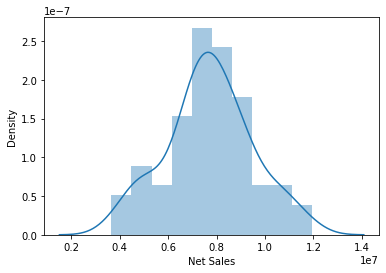

In [187]:
sns.distplot(a=final_data[target_column])

<AxesSubplot:xlabel='Products', ylabel='Net Sales'>

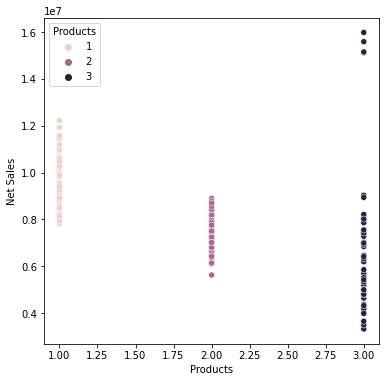

In [21]:
plt.figure(figsize=(6,6))
sns.sca`tterplot(data=financial_data, x='Products', y='Net Sales', hue='Products')

<AxesSubplot:xlabel='Advertising Spend (A)', ylabel='Net Sales'>

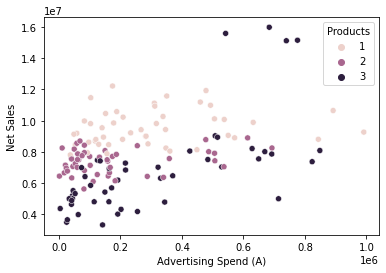

In [22]:
sns.scatterplot(data=financial_data, x='Advertising Spend (A)', y='Net Sales', hue='Products')

<AxesSubplot:xlabel='Promotion Spend (P)', ylabel='Net Sales'>

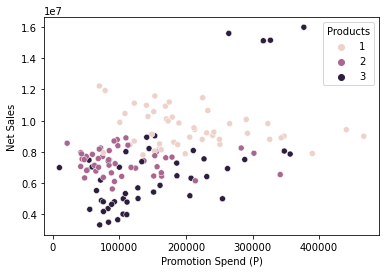

In [23]:
sns.scatterplot(data=financial_data, x='Promotion Spend (P)', y='Net Sales', hue='Products')

<AxesSubplot:>

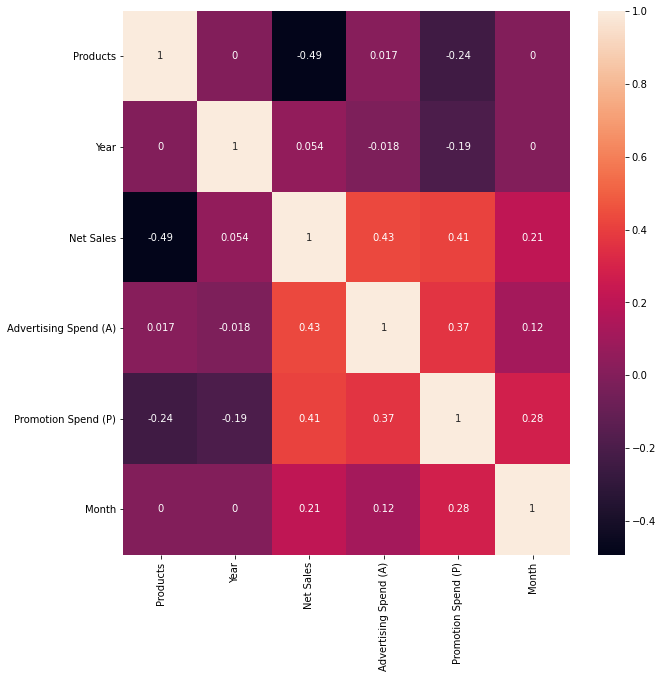

In [24]:
plt.figure(figsize=(10,10))
sns.heatmap(financial_data.corr(), annot=True)

### Find if the data is balanced

<AxesSubplot:xlabel='Products', ylabel='count'>

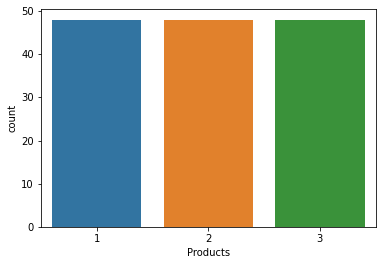

In [25]:
sns.countplot(x="Products", data=financial_data)

### Detect outliers

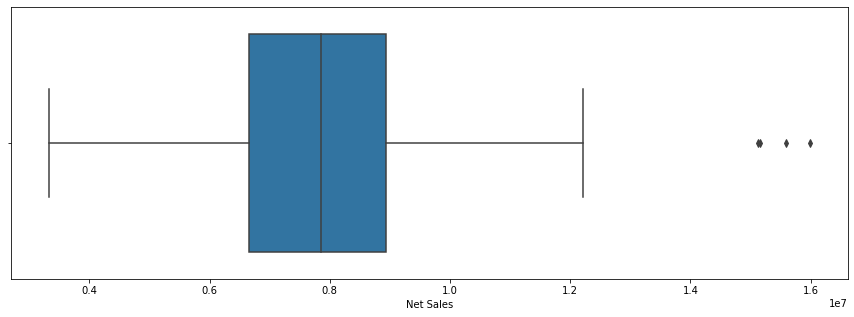

In [26]:
plt.figure(figsize=(15,5))
sns.boxplot(x=financial_data['Net Sales'])
plt.show()

In [27]:
Q1 = financial_data['Net Sales'].quantile(0.25)
Q3 = financial_data['Net Sales'].quantile(0.75)
IQR = Q3 - Q1

upr = financial_data['Net Sales'] >= (Q3+1.5*IQR)  
lwr = financial_data['Net Sales'] <= (Q1-1.5*IQR)
print("Upper bound: ", np.where(upr))
print("Lower Bound", np.where(lwr))

filter = (financial_data['Net Sales'] >= (Q1 - 1.5 * IQR)) & (financial_data['Net Sales'] <= (Q3 + 1.4 *IQR))

financial_data = financial_data.loc[filter]
financial_data.shape

Upper bound:  (array([ 33,  69, 105, 141], dtype=int64),)
Lower Bound (array([], dtype=int64),)


(139, 6)

<AxesSubplot:xlabel='Products', ylabel='Net Sales'>

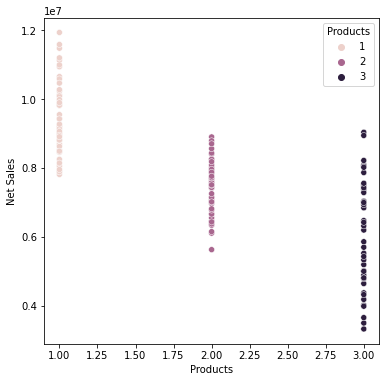

In [28]:
plt.figure(figsize=(6,6))
sns.scatterplot(data=financial_data, x='Products', y='Net Sales', hue='Products')

#### After removing outliers

<AxesSubplot:xlabel='Net Sales'>

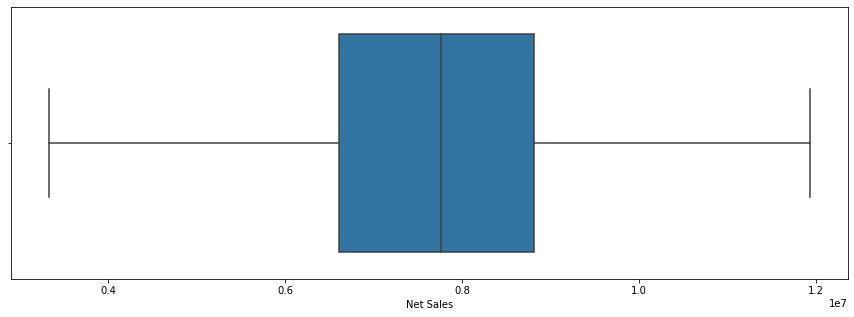

In [29]:
plt.figure(figsize=(15,5))
sns.boxplot(x=financial_data['Net Sales'])

#### Data after Removing outliers version 2

In [30]:
data_outliers = financial_data

In [31]:
financial_data.duplicated().sum()

0

### Using marketing data

In [32]:
marketing_data.head(5)

,BRAND,DATE,RATE OF INNOVATION,PRICE PER VOLUME,TDP,SHARE OF VOICE,NET SALES OF COMPETITOR #1,NET SALES OF COMPETITOR #2,PRICE PER VOLUME COMPETITOR #1,MARKET SIZE - SUB MARKET 1,...,MARKET SIZE - SUB MARKET 12,MARKET SIZE - SUB MARKET 13,MARKET SIZE - SUB MARKET 14,MARKET SIZE - SUB MARKET 15,MARKET SIZE - SUB MARKET 16,POPULATION - 0 À 19 ANS,POPULATION - 20 À 39 ANS,POPULATION - 40 À 59 ANS,POPULATION - 60 À 74 ANS,POPULATION - 75 ANS ET PLUS
0,1,2018-03-01,1.408282,8.317322,110.011542,45.192,4.032382e+06,2.691472e+08,15.004156,4.390130e+06,...,3.606671e+07,1.032834e+07,3.296905e+07,7.829776e+06,7.848957e+06,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04
1,1,2018-04-01,1.396744,8.908931,109.830905,63.484,5.264635e+06,3.269989e+08,15.484910,5.774614e+06,...,4.150016e+07,1.300159e+07,4.234487e+07,9.093001e+06,1.124655e+07,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04
2,1,2018-05-01,1.731032,9.249615,109.854779,55.952,4.339679e+06,2.583341e+08,15.653820,4.933605e+06,...,3.093176e+07,1.117407e+07,3.410793e+07,7.515288e+06,9.221574e+06,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04
3,1,2018-06-01,1.735802,9.064674,109.904309,32.280,4.651524e+06,2.546303e+08,15.675915,4.559039e+06,...,2.858196e+07,9.730342e+06,3.304539e+07,7.200092e+06,8.915028e+06,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04
4,1,2018-07-01,1.509909,9.176992,109.889601,37.660,5.723941e+06,3.152492e+08,15.365394,5.336451e+06,...,3.608451e+07,1.262302e+07,4.301778e+07,8.473812e+06,9.464171e+06,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04


In [33]:
marketing_data.duplicated().sum()

0

#### Extract Year and Month from Date

In [34]:
marketing_data['Year'] = pd.DatetimeIndex(marketing_data['DATE']).year
marketing_data['Month'] = pd.DatetimeIndex(marketing_data['DATE']).month

In [35]:
financial_data = financial_data.rename(columns={"Products": "BRAND"})

In [36]:
financial_data.shape, marketing_data.shape

((139, 6), (102, 32))

In [37]:
final_data = pd.merge(marketing_data, financial_data, on=['Month', 'Year', 'BRAND'])
final_data.head()

,BRAND,DATE,RATE OF INNOVATION,PRICE PER VOLUME,TDP,SHARE OF VOICE,NET SALES OF COMPETITOR #1,NET SALES OF COMPETITOR #2,PRICE PER VOLUME COMPETITOR #1,MARKET SIZE - SUB MARKET 1,...,POPULATION - 0 À 19 ANS,POPULATION - 20 À 39 ANS,POPULATION - 40 À 59 ANS,POPULATION - 60 À 74 ANS,POPULATION - 75 ANS ET PLUS,Year,Month,Net Sales,Advertising Spend (A),Promotion Spend (P)
0,1,2018-03-01,1.408282,8.317322,110.011542,45.192,4.032382e+06,2.691472e+08,15.004156,4.390130e+06,...,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04,2018,3,9.431472e+06,346736.76567,213335.57328
1,1,2018-04-01,1.396744,8.908931,109.830905,63.484,5.264635e+06,3.269989e+08,15.484910,5.774614e+06,...,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04,2018,4,7.896658e+06,63115.10190,389773.91552
2,1,2018-05-01,1.731032,9.249615,109.854779,55.952,4.339679e+06,2.583341e+08,15.653820,4.933605e+06,...,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04,2018,5,1.064950e+07,891552.82018,232935.34176
3,1,2018-06-01,1.735802,9.064674,109.904309,32.280,4.651524e+06,2.546303e+08,15.675915,4.559039e+06,...,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04,2018,6,9.007028e+06,283318.10388,347393.54576
4,1,2018-07-01,1.509909,9.176992,109.889601,37.660,5.723941e+06,3.152492e+08,15.365394,5.336451e+06,...,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04,2018,7,8.051880e+06,360860.70076,152840.18480


In [38]:
final_data.shape

(95, 35)

<AxesSubplot:xlabel='BRAND', ylabel='count'>

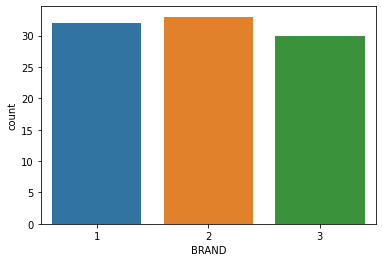

In [39]:
sns.countplot(x=final_data['BRAND'])

##### Merged Dataset version 3

In [40]:
data_merged = final_data.drop('DATE', axis=1)

<AxesSubplot:>

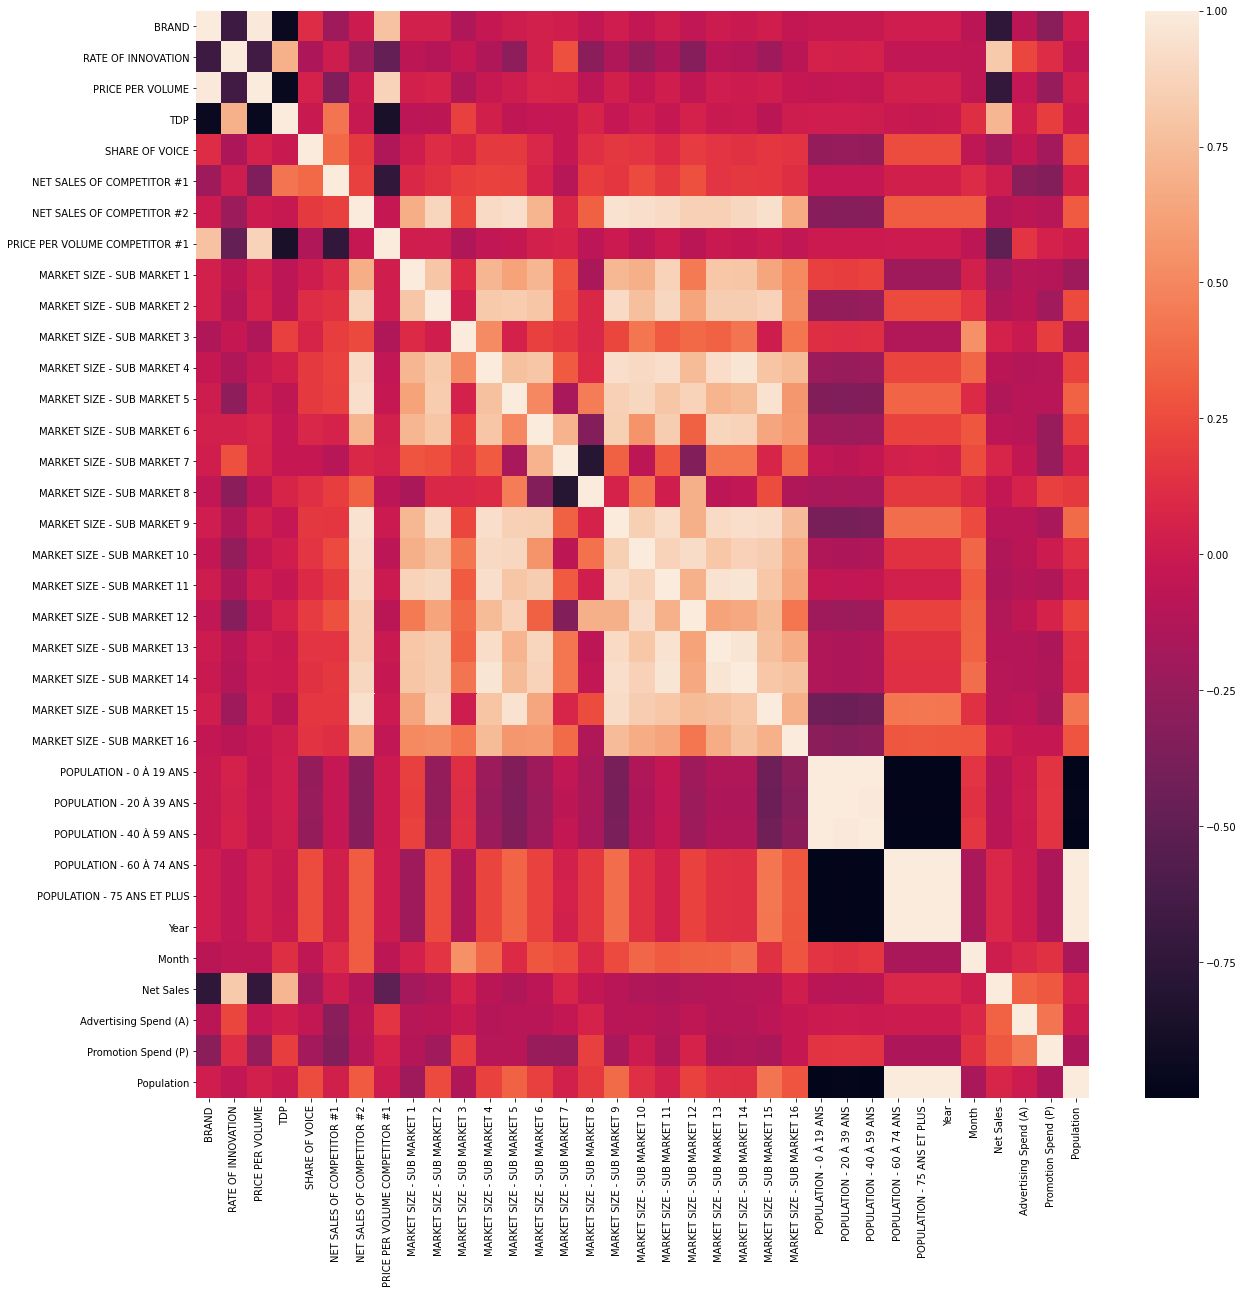

In [358]:
plt.figure(figsize=(20,20))
sns.heatmap(final_data.corr())

### Visualizing Merged Data

In [41]:
final_data.columns

Index(['BRAND', 'DATE', 'RATE OF INNOVATION', 'PRICE PER VOLUME', 'TDP',
       'SHARE OF VOICE', 'NET SALES OF COMPETITOR #1',
       'NET SALES OF COMPETITOR #2', 'PRICE PER VOLUME COMPETITOR #1',
       'MARKET SIZE - SUB MARKET 1', 'MARKET SIZE - SUB MARKET 2',
       'MARKET SIZE - SUB MARKET 3', 'MARKET SIZE - SUB MARKET 4',
       'MARKET SIZE - SUB MARKET 5', 'MARKET SIZE - SUB MARKET 6',
       'MARKET SIZE - SUB MARKET 7', 'MARKET SIZE - SUB MARKET 8',
       'MARKET SIZE - SUB MARKET 9', 'MARKET SIZE - SUB MARKET 10',
       'MARKET SIZE - SUB MARKET 11', 'MARKET SIZE - SUB MARKET 12',
       'MARKET SIZE - SUB MARKET 13', 'MARKET SIZE - SUB MARKET 14',
       'MARKET SIZE - SUB MARKET 15', 'MARKET SIZE - SUB MARKET 16',
       'POPULATION - 0 À 19 ANS', 'POPULATION - 20 À 39 ANS',
       'POPULATION - 40 À 59 ANS', 'POPULATION - 60 À 74 ANS',
       'POPULATION - 75 ANS ET PLUS', 'Year', 'Month', 'Net Sales',
       'Advertising Spend (A)', 'Promotion Spend (P)'],
      dty

#### Brand, Innovation and Price contribution towards Sales

<AxesSubplot:xlabel='BRAND', ylabel='Net Sales'>

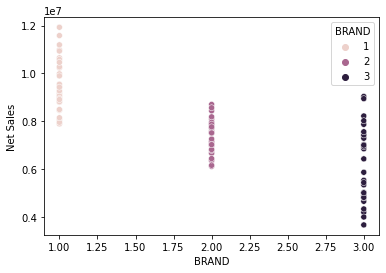

In [42]:
sns.scatterplot(x='BRAND', y='Net Sales', hue='BRAND',data=final_data) # Brand is closely correlated to Net Sales

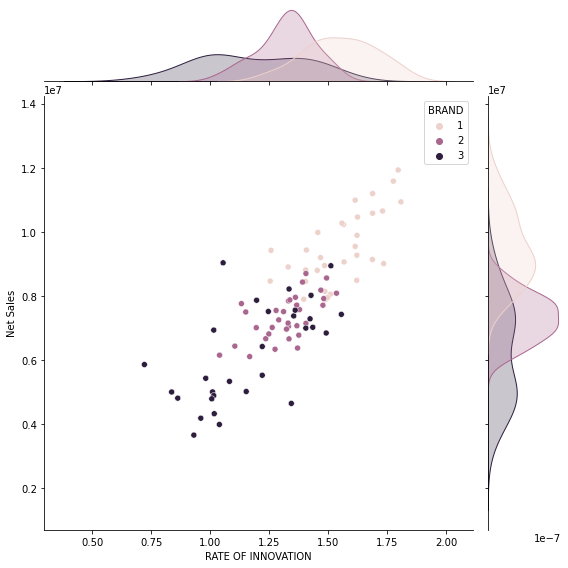

In [43]:
sns.jointplot(x="RATE OF INNOVATION", y=target_column, hue='BRAND', data=final_data,height=8)
plt.show()

<AxesSubplot:xlabel='PRICE PER VOLUME', ylabel='Net Sales'>

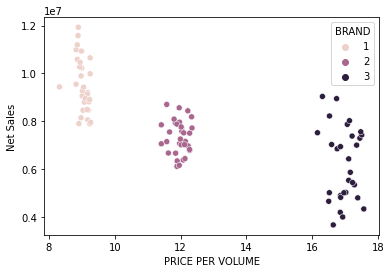

In [44]:
sns.scatterplot(x='PRICE PER VOLUME', y=target_column, hue='BRAND', data=final_data)

<AxesSubplot:xlabel='TDP', ylabel='Net Sales'>

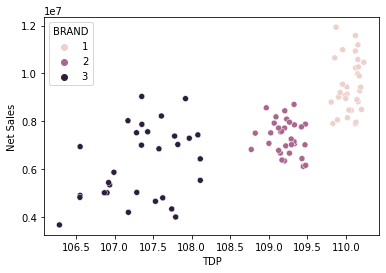

In [45]:
sns.scatterplot(x='TDP', y=target_column, hue='BRAND', data=final_data)

<AxesSubplot:xlabel='SHARE OF VOICE', ylabel='Net Sales'>

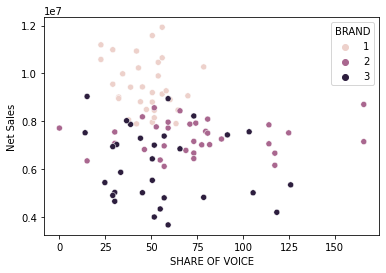

In [46]:
sns.scatterplot(x='SHARE OF VOICE', y=target_column, hue='BRAND', data=final_data)

In [354]:
branding_features = ['BRAND', 'DATE', 'RATE OF INNOVATION', 'PRICE PER VOLUME', 'TDP', 'SHARE OF VOICE', target_column, 'Advertising Spend (A)', 'Promotion Spend (P)']

<AxesSubplot:>

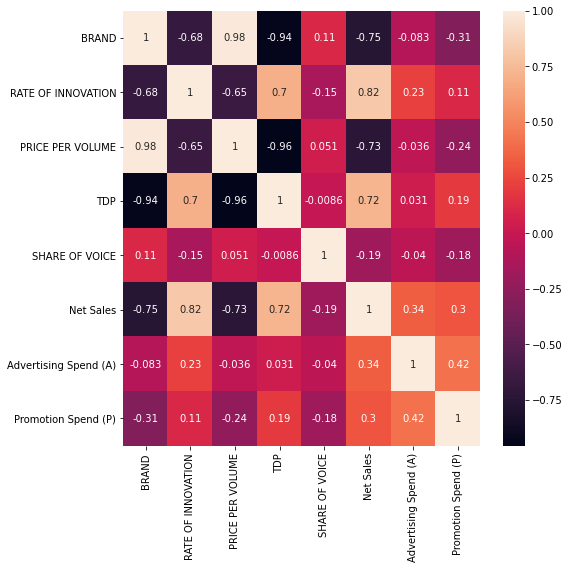

In [355]:
plt.figure(figsize=(8,8))
sns.heatmap(final_data[branding_features].corr(), annot=True)

###### TDP seems to be too much correlated with all the good predictors so we can ignore it

#### Date and Year Contribution

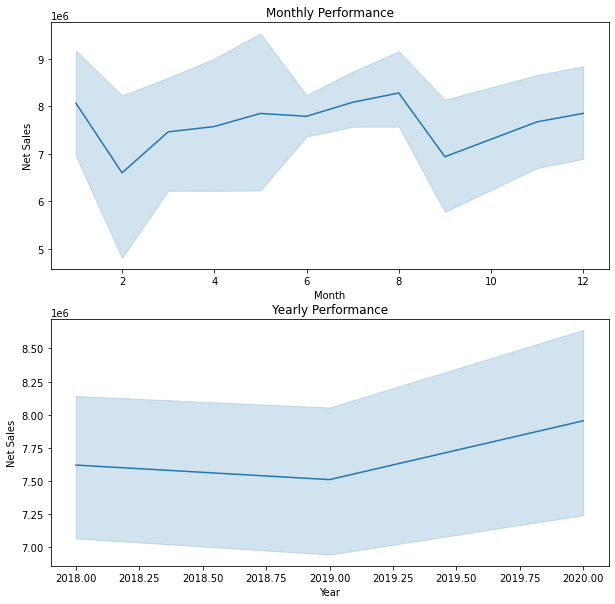

In [166]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

sns.lineplot(x="Month", y="Net Sales", data=final_data, ax=ax[0]).set_title("Monthly Performance")
sns.lineplot(x="Year", y="Net Sales", data=final_data, ax=ax[1]).set_title("Yearly Performance")

plt.show()

#### Checking Competitor data

In [199]:
competitor_cols=['NET SALES OF COMPETITOR #1','NET SALES OF COMPETITOR #2', 'PRICE PER VOLUME COMPETITOR #1', target_column]

competitor = final_data[competitor_cols]

<AxesSubplot:>

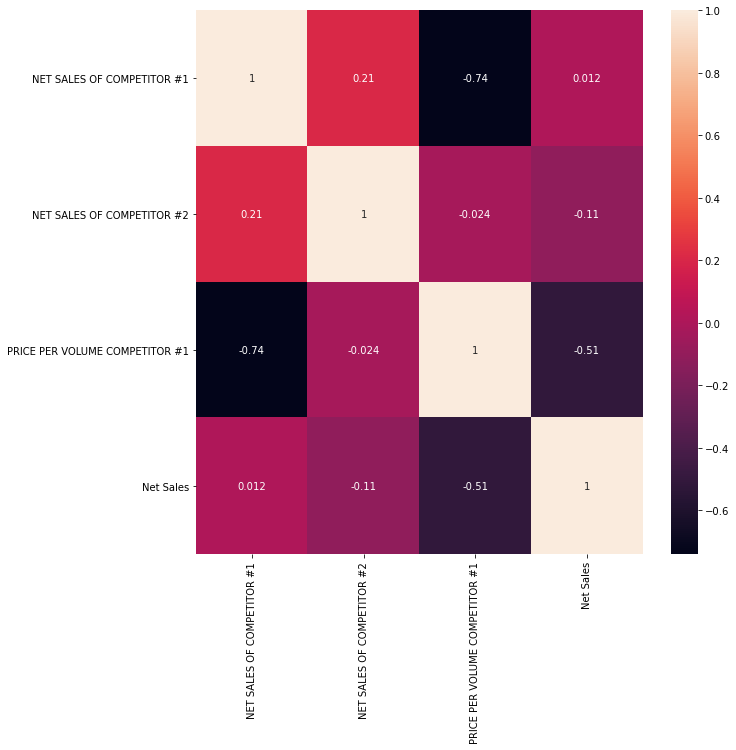

In [174]:
plt.figure(figsize=(10,10))
sns.heatmap(competitor.corr(), annot=True)

#### Checking Sub Segment Data

In [364]:
sub_markets_cols = ['MARKET SIZE - SUB MARKET 1', 'MARKET SIZE - SUB MARKET 2',
       'MARKET SIZE - SUB MARKET 3', 'MARKET SIZE - SUB MARKET 4',
       'MARKET SIZE - SUB MARKET 5', 'MARKET SIZE - SUB MARKET 6',
       'MARKET SIZE - SUB MARKET 7', 'MARKET SIZE - SUB MARKET 8',
       'MARKET SIZE - SUB MARKET 9', 'MARKET SIZE - SUB MARKET 10',
       'MARKET SIZE - SUB MARKET 11', 'MARKET SIZE - SUB MARKET 12',
       'MARKET SIZE - SUB MARKET 13', 'MARKET SIZE - SUB MARKET 14',
       'MARKET SIZE - SUB MARKET 15', 'MARKET SIZE - SUB MARKET 16', target_column]
sub_markets = final_data[sub_markets_cols]
sub_markets

,MARKET SIZE - SUB MARKET 1,MARKET SIZE - SUB MARKET 2,MARKET SIZE - SUB MARKET 3,MARKET SIZE - SUB MARKET 4,MARKET SIZE - SUB MARKET 5,MARKET SIZE - SUB MARKET 6,MARKET SIZE - SUB MARKET 7,MARKET SIZE - SUB MARKET 8,MARKET SIZE - SUB MARKET 9,MARKET SIZE - SUB MARKET 10,MARKET SIZE - SUB MARKET 11,MARKET SIZE - SUB MARKET 12,MARKET SIZE - SUB MARKET 13,MARKET SIZE - SUB MARKET 14,MARKET SIZE - SUB MARKET 15,MARKET SIZE - SUB MARKET 16,Net Sales
0,4.390130e+06,2.157694e+07,7.730121e+06,2.393471e+07,7.583373e+07,1.231558e+07,1.903435e+07,4.469266e+07,6.495177e+07,2.085323e+07,7.505574e+07,3.606671e+07,1.032834e+07,3.296905e+07,7.829776e+06,7.848957e+06,9.431472e+06
1,5.774614e+06,2.546356e+07,1.262462e+07,3.025242e+07,8.834493e+07,1.603307e+07,4.186732e+07,2.416054e+07,8.545636e+07,2.574195e+07,9.371433e+07,4.150016e+07,1.300159e+07,4.234487e+07,9.093001e+06,1.124655e+07,7.896658e+06
2,4.933605e+06,2.468336e+07,9.263539e+06,2.493336e+07,6.857002e+07,1.364631e+07,4.910338e+07,1.105004e+07,6.973742e+07,1.966570e+07,7.626576e+07,3.093176e+07,1.117407e+07,3.410793e+07,7.515288e+06,9.221574e+06,1.064950e+07
3,4.559039e+06,2.363557e+07,1.011697e+07,2.385866e+07,6.599316e+07,1.374952e+07,5.613054e+07,8.585693e+06,6.679396e+07,1.909652e+07,7.420279e+07,2.858196e+07,9.730342e+06,3.304539e+07,7.200092e+06,8.915028e+06,9.007028e+06
4,5.336451e+06,2.848700e+07,1.433186e+07,3.049578e+07,7.348830e+07,1.875900e+07,8.813266e+07,8.564702e+06,8.538215e+07,2.264039e+07,9.214862e+07,3.608451e+07,1.262302e+07,4.301778e+07,8.473812e+06,9.464171e+06,8.051880e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,4.184780e+06,2.315039e+07,1.110312e+07,2.612836e+07,7.420191e+07,1.522209e+07,6.950381e+07,1.328871e+07,7.988840e+07,2.135977e+07,7.530288e+07,3.344091e+07,1.121204e+07,3.656339e+07,8.708255e+06,1.207957e+07,8.016969e+06
91,3.930409e+06,2.348721e+07,1.103767e+07,2.606580e+07,7.016171e+07,1.597909e+07,7.733079e+07,9.831625e+06,7.694263e+07,1.892835e+07,7.638133e+07,3.242286e+07,1.124883e+07,3.609620e+07,8.087232e+06,1.005379e+07,7.553435e+06
92,4.939757e+06,2.966062e+07,1.427940e+07,3.432265e+07,8.836171e+07,2.010477e+07,1.019575e+08,1.312985e+07,9.773030e+07,2.434326e+07,9.510805e+07,4.108314e+07,1.454102e+07,4.570182e+07,1.006484e+07,1.161773e+07,6.994110e+06
93,4.006049e+06,2.521610e+07,8.066319e+06,2.631724e+07,7.891903e+07,1.486226e+07,5.213480e+07,2.743611e+07,7.699286e+07,2.127101e+07,7.695103e+07,3.771599e+07,1.098663e+07,3.590545e+07,8.595609e+06,8.400586e+06,5.427936e+06


<AxesSubplot:>

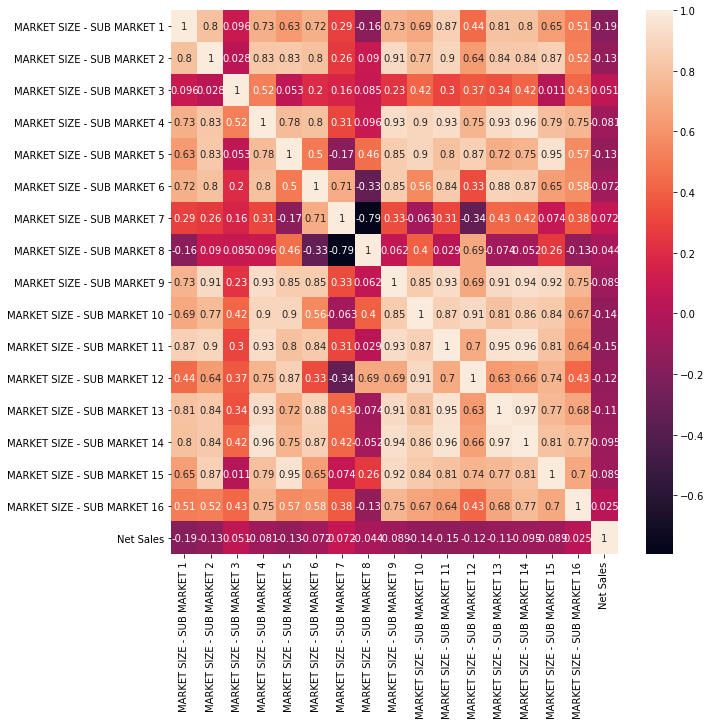

In [367]:
plt.figure(figsize=(10,10))
sns.heatmap(sub_markets.corr(), annot=True)

#### Exploring Population data

In [239]:
plt.figure(figsize=(10,10))
market_features = ['POPULATION - 0 À 19 ANS', 'POPULATION - 20 À 39 ANS','POPULATION - 40 À 59 ANS', 
                   'POPULATION - 60 À 74 ANS', 'POPULATION - 75 ANS ET PLUS', 'Net Sales', 'Advertising Spend (A)', 'Promotion Spend (P)']

market = final_data[market_features]
market.head(3)

,POPULATION - 0 À 19 ANS,POPULATION - 20 À 39 ANS,POPULATION - 40 À 59 ANS,POPULATION - 60 À 74 ANS,POPULATION - 75 ANS ET PLUS,Net Sales,Advertising Spend (A),Promotion Spend (P)
0,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04,9.431472e+06,346736.76567,213335.57328
1,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04,7.896658e+06,63115.10190,389773.91552
2,1.445336e+07,1.700291e+07,1.534917e+07,8230287.67,4576453.04,1.064950e+07,891552.82018,232935.34176


<Figure size 720x720 with 0 Axes>

In [240]:
for col in market_features[:5]:
    print("Column name-> ", col, "\n\tDuplicates:" ,market[col].duplicated().sum(), "Unique: ",market[col].unique())

Column name->  POPULATION - 0 À 19 ANS 
	Duplicates: 92 Unique:  [14453363.186 14408267.558 14356759.948]
Column name->  POPULATION - 20 À 39 ANS 
	Duplicates: 92 Unique:  [17002912.153 16977669.856 16935346.008]
Column name->  POPULATION - 40 À 59 ANS 
	Duplicates: 92 Unique:  [15349170.375 15286979.75  15228901.625]
Column name->  POPULATION - 60 À 74 ANS 
	Duplicates: 92 Unique:  [8230287.67  8389412.22  8551375.965]
Column name->  POPULATION - 75 ANS ET PLUS 
	Duplicates: 92 Unique:  [4576453.04 4638567.16 4705049.5 ]


<AxesSubplot:>

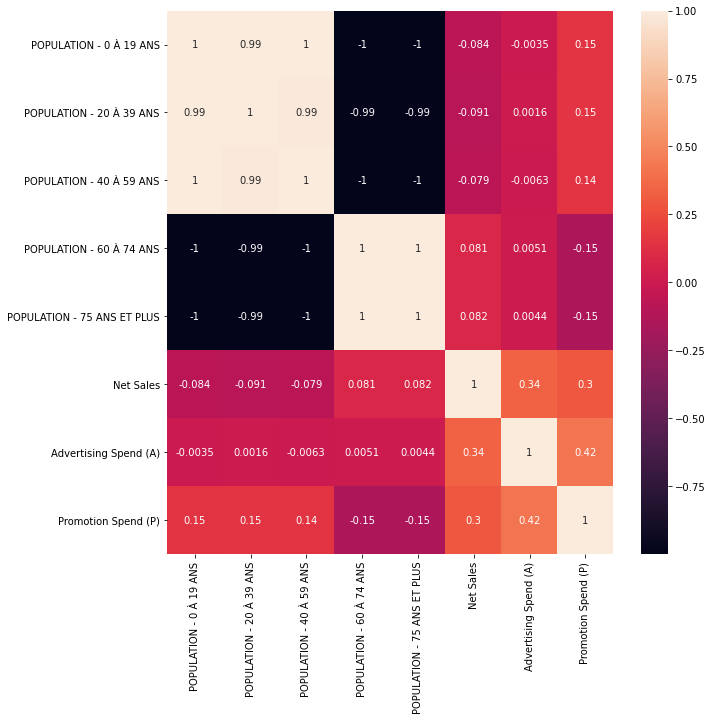

In [241]:
plt.figure(figsize=(10,10))
sns.heatmap(final_data[market_features].corr(),annot=True)

###### Combining population features into on as all those are strongly correlated withing themselves and they don't contribute much to the dataset.

In [243]:
population_features = ['POPULATION - 0 À 19 ANS', 'POPULATION - 20 À 39 ANS', 
                       'POPULATION - 40 À 59 ANS', 'POPULATION - 60 À 74 ANS',
                       'POPULATION - 75 ANS ET PLUS']

In [244]:
def combine_population(data):
    return data[population_features].sum()

In [245]:
final_data['Population'] = final_data.apply(lambda x: combine_population(x), axis=1)
final_data.head()

,BRAND,DATE,RATE OF INNOVATION,PRICE PER VOLUME,TDP,SHARE OF VOICE,NET SALES OF COMPETITOR #1,NET SALES OF COMPETITOR #2,PRICE PER VOLUME COMPETITOR #1,MARKET SIZE - SUB MARKET 1,...,POPULATION - 20 À 39 ANS,POPULATION - 40 À 59 ANS,POPULATION - 60 À 74 ANS,POPULATION - 75 ANS ET PLUS,Year,Month,Net Sales,Advertising Spend (A),Promotion Spend (P),Population
0,1,2018-03-01,1.408282,8.317322,110.011542,45.192,4.032382e+06,2.691472e+08,15.004156,4.390130e+06,...,1.700291e+07,1.534917e+07,8230287.67,4576453.04,2018,3,9.431472e+06,346736.76567,213335.57328,5.961219e+07
1,1,2018-04-01,1.396744,8.908931,109.830905,63.484,5.264635e+06,3.269989e+08,15.484910,5.774614e+06,...,1.700291e+07,1.534917e+07,8230287.67,4576453.04,2018,4,7.896658e+06,63115.10190,389773.91552,5.961219e+07
2,1,2018-05-01,1.731032,9.249615,109.854779,55.952,4.339679e+06,2.583341e+08,15.653820,4.933605e+06,...,1.700291e+07,1.534917e+07,8230287.67,4576453.04,2018,5,1.064950e+07,891552.82018,232935.34176,5.961219e+07
3,1,2018-06-01,1.735802,9.064674,109.904309,32.280,4.651524e+06,2.546303e+08,15.675915,4.559039e+06,...,1.700291e+07,1.534917e+07,8230287.67,4576453.04,2018,6,9.007028e+06,283318.10388,347393.54576,5.961219e+07
4,1,2018-07-01,1.509909,9.176992,109.889601,37.660,5.723941e+06,3.152492e+08,15.365394,5.336451e+06,...,1.700291e+07,1.534917e+07,8230287.67,4576453.04,2018,7,8.051880e+06,360860.70076,152840.18480,5.961219e+07


<AxesSubplot:>

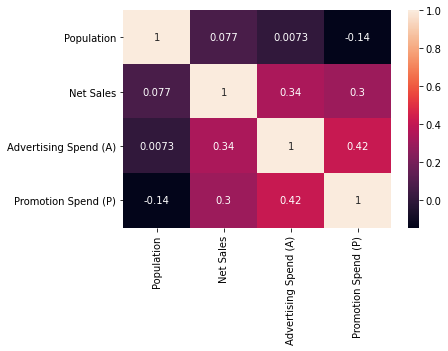

In [291]:
sns.heatmap(final_data[['Population', 'Net Sales', 'Advertising Spend (A)', 'Promotion Spend (P)']].corr(), annot=True)

##### There summed up values of correlation has almost similar correlation with the important features so we can drop the other

# Model Training

In [343]:
data_final = final_data

In [344]:
drop_columns = ['TDP', 'DATE', 'Year', 'Month' ,'POPULATION - 0 À 19 ANS', 'POPULATION - 20 À 39 ANS', 'POPULATION - 40 À 59 ANS', 'POPULATION - 60 À 74 ANS','POPULATION - 75 ANS ET PLUS']
data_final = data_final.drop(columns=drop_columns, axis=1)
data_final.head()

,BRAND,RATE OF INNOVATION,PRICE PER VOLUME,SHARE OF VOICE,NET SALES OF COMPETITOR #1,NET SALES OF COMPETITOR #2,PRICE PER VOLUME COMPETITOR #1,MARKET SIZE - SUB MARKET 1,MARKET SIZE - SUB MARKET 2,MARKET SIZE - SUB MARKET 3,...,MARKET SIZE - SUB MARKET 11,MARKET SIZE - SUB MARKET 12,MARKET SIZE - SUB MARKET 13,MARKET SIZE - SUB MARKET 14,MARKET SIZE - SUB MARKET 15,MARKET SIZE - SUB MARKET 16,Net Sales,Advertising Spend (A),Promotion Spend (P),Population
0,1,1.408282,8.317322,45.192,4.032382e+06,2.691472e+08,15.004156,4.390130e+06,2.157694e+07,7.730121e+06,...,7.505574e+07,3.606671e+07,1.032834e+07,3.296905e+07,7.829776e+06,7.848957e+06,9.431472e+06,346736.76567,213335.57328,5.961219e+07
1,1,1.396744,8.908931,63.484,5.264635e+06,3.269989e+08,15.484910,5.774614e+06,2.546356e+07,1.262462e+07,...,9.371433e+07,4.150016e+07,1.300159e+07,4.234487e+07,9.093001e+06,1.124655e+07,7.896658e+06,63115.10190,389773.91552,5.961219e+07
2,1,1.731032,9.249615,55.952,4.339679e+06,2.583341e+08,15.653820,4.933605e+06,2.468336e+07,9.263539e+06,...,7.626576e+07,3.093176e+07,1.117407e+07,3.410793e+07,7.515288e+06,9.221574e+06,1.064950e+07,891552.82018,232935.34176,5.961219e+07
3,1,1.735802,9.064674,32.280,4.651524e+06,2.546303e+08,15.675915,4.559039e+06,2.363557e+07,1.011697e+07,...,7.420279e+07,2.858196e+07,9.730342e+06,3.304539e+07,7.200092e+06,8.915028e+06,9.007028e+06,283318.10388,347393.54576,5.961219e+07
4,1,1.509909,9.176992,37.660,5.723941e+06,3.152492e+08,15.365394,5.336451e+06,2.848700e+07,1.433186e+07,...,9.214862e+07,3.608451e+07,1.262302e+07,4.301778e+07,8.473812e+06,9.464171e+06,8.051880e+06,360860.70076,152840.18480,5.961219e+07


## Linear Regression

In [345]:
X, y = data_final.drop(target_column, axis=1), data_final[target_column]
X.shape, y.shape

((95, 26), (95,))

In [346]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15 ,random_state=0)
X_train.shape, X_test.shape

((80, 26), (15, 26))

In [347]:
X_train.head()

,BRAND,RATE OF INNOVATION,PRICE PER VOLUME,SHARE OF VOICE,NET SALES OF COMPETITOR #1,NET SALES OF COMPETITOR #2,PRICE PER VOLUME COMPETITOR #1,MARKET SIZE - SUB MARKET 1,MARKET SIZE - SUB MARKET 2,MARKET SIZE - SUB MARKET 3,...,MARKET SIZE - SUB MARKET 10,MARKET SIZE - SUB MARKET 11,MARKET SIZE - SUB MARKET 12,MARKET SIZE - SUB MARKET 13,MARKET SIZE - SUB MARKET 14,MARKET SIZE - SUB MARKET 15,MARKET SIZE - SUB MARKET 16,Advertising Spend (A),Promotion Spend (P),Population
60,2,1.391874,12.219945,65.636,1.181248e+07,2.842060e+08,13.896974,3.930409e+06,2.348721e+07,1.103767e+07,...,1.892835e+07,7.638133e+07,3.242286e+07,1.124883e+07,3.609620e+07,8.087232e+06,1.005379e+07,82783.61268,113047.56192,5.977743e+07
8,1,1.254668,9.194360,64.560,6.601889e+06,3.670058e+08,14.637696,4.900989e+06,2.630228e+07,2.447166e+07,...,3.090711e+07,9.608997e+07,5.467440e+07,1.306548e+07,4.499838e+07,9.201008e+06,1.301889e+07,161786.15863,187724.28896,5.961219e+07
22,1,1.688837,8.860033,22.596,5.168073e+06,2.890999e+08,14.521654,4.023739e+06,2.561574e+07,9.778230e+06,...,2.109142e+07,7.389864e+07,3.964597e+07,1.044063e+07,3.280774e+07,8.100887e+06,7.077706e+06,459756.99355,175015.00240,5.977743e+07
73,3,1.015551,16.859731,29.052,1.277310e+06,2.801850e+08,22.593868,4.132439e+06,2.362797e+07,8.240214e+06,...,2.088047e+07,7.321562e+07,3.844515e+07,9.981036e+06,3.194605e+07,8.033096e+06,6.428732e+06,41589.00736,73191.08912,5.970090e+07
45,2,1.330611,12.144686,73.168,1.310147e+07,2.718654e+08,13.803892,4.294235e+06,2.186049e+07,1.109292e+07,...,2.150763e+07,7.709113e+07,3.428774e+07,1.060665e+07,3.578250e+07,7.695604e+06,9.502543e+06,21199.51256,84677.69168,5.970090e+07


In [348]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [360]:
from sklearn.linear_model import LinearRegression

regr = LinearRegression()
regr.fit(X_train, y_train)
# y_pred = model.predict(X_test)

LinearRegression()

### OLS

In [350]:
import statsmodels.api as sm
X_sm = sm.add_constant(X)
regressor = sm.OLS(y, X_sm).fit()
print(regressor.summary())

                            OLS Regression Results                            
Dep. Variable:              Net Sales   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     20.00
Date:                Sat, 29 May 2021   Prob (F-statistic):           1.30e-22
Time:                        00:49:34   Log-Likelihood:                -1399.1
No. Observations:                  95   AIC:                             2852.
Df Residuals:                      68   BIC:                             2921.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [351]:
from sklearn.neighbors import KNeighborsRegressor
neigh = KNeighborsRegressor(n_neighbors=10)
neigh.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=10)

In [352]:
neigh.score(X_test,y_test)

0.6394771021375178

# Evaluation

In [361]:
regr.score(X_test, y_test)

0.8723096119284104

In [362]:
y_pred = regr.predict(X_test)

print("Residual sum of squares (RSS): %.2f" % sum((y_pred - y_test) ** 2))
print("Mean absolute error (MAE): %.2f" % np.mean(abs(y_pred - y_test)))
print("Mean square error (MSE): %.2f" % np.mean((y_pred - y_test) ** 2))
print("Root mean square error (RMSE): %.2f" % np.sqrt(np.mean((y_pred - y_test) ** 2)))

Residual sum of squares (RSS): 5134647123802.18
Mean absolute error (MAE): 505365.41
Mean square error (MSE): 342309808253.48
Root mean square error (RMSE): 585072.48
